In [9]:
import itertools

№ 1<br/>
**(2 балла)**<br/>
Предположим, что вы собираетесь в турпоход. У вас есть рюкзак, емкость которого
составляет 6 фунтов, и список предметов, которые вы можете положить с собой в рюкзак.
У каждого предмета есть вес и ценность. Чем выше ценность, тем важнее для вас предмет.
Нарисуйте и вручную заполните таблицу, которая даст оптимальный набор предметов для
похода и общую ценность получившегося рюкзака. Ориентируйтесь на алгоритм
динамического программирования, описанный в лекции.
Список предметов возьмите согласно вашему варианту.


Вариант 4.
1. вода, 2 фунта, 6;
2. книга, 1 фунт, 3;
3. еда, 4 фунта, 9;
4. куртка, 1 фунт, 5;
5. камера, 3 фунта, 6 

In [ ]:
states_needed = set(["mt", "wa", "or", "id", "nv", "ut", "ca", "az"])

stations = {}
stations["kone"] = set(["id", "nv", "ut"])
stations["ktwo"] = set(["wa", "id", "mt"])
stations["kthree"] = set(["or", "nv", "ca"])
stations["kfour"] = set(["nv", "ut"])
stations["kfive"] = set(["ca", "az"])

final_stations = set()

while states_needed:
  best_station = None
  states_covered = set()
  for station, states_for_station in stations.items():
    covered = states_needed & states_for_station
    if len(covered) > len(states_covered):
      best_station = station
      states_covered = covered

  states_needed -= states_covered
  final_stations.add(best_station)

print(final_stations)

In [ ]:
# ======= ПАРАМЕТРЫ =======

items = [
    {"name": "вода",    "weight": 2,    "value": 6},
    {"name": "книга",   "weight": 1,    "value": 3},
    {"name": "еда",     "weight": 4,    "value": 9},
    {"name": "куртка",  "weight": 1,    "value": 5},
    {"name": "камера",  "weight": 3,    "value": 6},
]

capacity = 6

# ======= ТАБЛИЦА =======

n = len(items)

dp = [[0] * (capacity + 1) for _ in range(n+1)]

for i in range(1, n + 1):
    weight = items[i-1]["weight"]
    value = items[i-1]["value"]
    for w in range(capacity + 1):
        if weight > w:
            dp[i][w] = dp[i-1][w]
        else:
            dp[i][w] = max(dp[i - 1][w], dp[i - 1][w - weight] + value)

print(f"{'i\\w':<4}", end="")
for w in range(capacity + 1):
    print(f"{w:>4}", end="")
print("\n" + "-"*35)

for i in range(n + 1):
    if i == 0:
        print(f"{'0':<4}", end="")
    else:
        print(f"{i:<4}", end="")
    
    for w in range(capacity + 1):
        print(f"{dp[i][w]:>4}", end="")
    print()

i\w    0   1   2   3   4   5   6
-----------------------------------
0      0   0   0   0   0   0   0
1      0   0   6   6   6   6   6
2      0   3   6   9   9   9   9
3      0   3   6   9   9  12  15
4      0   5   8  11  14  14  17
5      0   5   8  11  14  14  17


№ 2<br/>
**(3 балла)**<br/>
Напишите программу, которая моделирует задачу о рюкзаке. Пользователь вводит объем
рюкзака и список предметов с указанием их веса и ценности. Вам необходимо подобрать
набор предметов максимальной ценности, которые поместятся в рюкзаке. Реализуйте три
варианта решения этой задачи:

1. Полный перебор
2. Жадный алгоритм
3. Динамическое программирование

Укажите вычислительная сложность (в O-нотации) для каждого алгоритма. Постройте
графики возрастания времени выполнения алгоритмов при увеличении входных данных.

Приведите примеры входных данных, когда жадный алгоритм дает оптимальное решение
и когда дает неоптимальное решение.


In [10]:
# ======= АЛГОРИТМЫ =======

def knapsack_brute_force(capacity, items):
    """
    Полный перебор. Перебирает все возможные комбинации предметов
    """
    n = len(items)
    max_value = 0
    best_combination = []

    for r in range(1, n + 1):
        for combination in itertools.combinations(items, r):
            current_weight = sum(item['weight'] for item in combination)
            current_value = sum(item['value'] for item in combination)

            if current_weight <= capacity:
                if current_value > max_value:
                    max_value = current_value
                    best_combination = combination
    
    return max_value, [item['name'] for item in best_combination]
    pass

def knapsack_greedy(capacity, items):
    """
    Жадный алгоритм. Выбирает предметы с максимальной удельной ценностью (оптимальный вариант)
    """
    sorted_items = sorted(items, key=lambda x: x['value'] / x['weight'], reverse=True)

    total_value = 0
    current_weight = 0
    selected_items = []

    for item in sorted_items:
        if current_weight + item['weight'] <= capacity:
            current_weight += item['weight']
            total_value += item['value']
            selected_items.append(item['name'])
    return total_value, selected_items
    pass

def knapsack_dp(capacity, items):
    """
    Динамическое программирование – метод решения сложных задач, 
    разбиваемых на подзадачи, которые решаются в первую очередь.
    """
    n = len(items)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        item = items[i-1]
        w, v = item['weight'], item['value']
        for j in range(capacity + 1):
            if w <= j:
                dp[i][j] = max(dp[i-1][j], dp[i-1][j-w] + v)
            else:
                dp[i][j] = dp[i-1][j]
                
    # Восстановление ответа (какие предметы взяли)
    res = dp[n][capacity]
    w_curr = capacity
    selected_items = []
    for i in range(n, 0, -1):
        if res <= 0: break
        if res == dp[i-1][w_curr]:
            continue
        else:
            item = items[i-1]
            selected_items.append(item['name'])
            res -= item['value']
            w_curr -= item['weight']
            
    return dp[n][capacity], selected_items

    return
    pass

# ======= ПАРАМЕТРЫ =======

items = [
    {"name": "вода",    "weight": 2,    "value": 6},
    {"name": "книга",   "weight": 1,    "value": 3},
    {"name": "еда",     "weight": 4,    "value": 9},
    {"name": "куртка",  "weight": 1,    "value": 5},
    {"name": "камера",  "weight": 3,    "value": 6},
]

capacity = 6

# ======= ВЫВОД =======

print("Brute Force:", knapsack_brute_force(capacity, items))
print("Greedy:", knapsack_greedy(capacity, items))
print("DP:", knapsack_dp(capacity, items))

Brute Force: (17, ['вода', 'куртка', 'камера'])
Greedy: (14, ['куртка', 'вода', 'книга'])
DP: (17, ['куртка', 'еда', 'книга'])


№ 3<br/>
**(2 балла)**<br/>
Нарисуйте и вручную заполните таблицу для вычисления самой длинной общей подстроки
между строками blue и clue. Ориентируйтесь на алгоритм динамического
программирования, описанный в лекции.


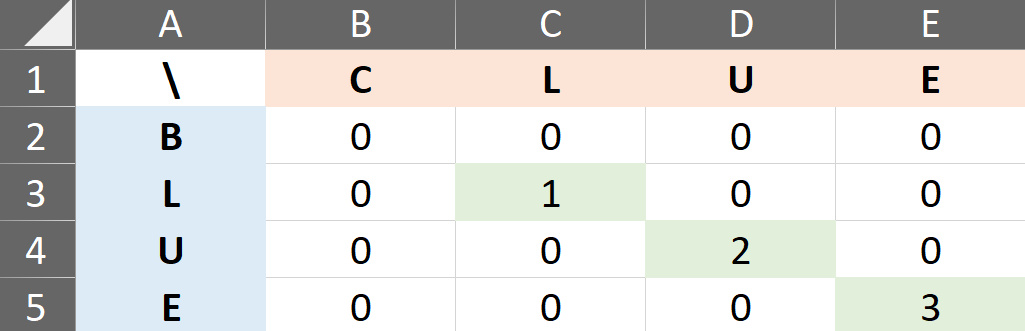
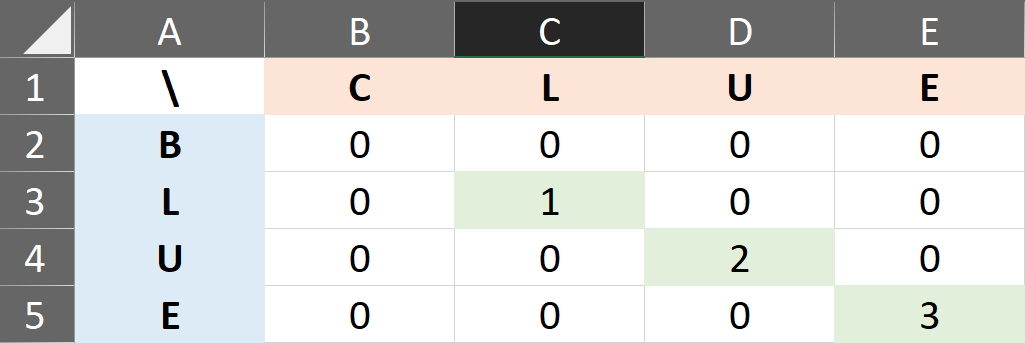
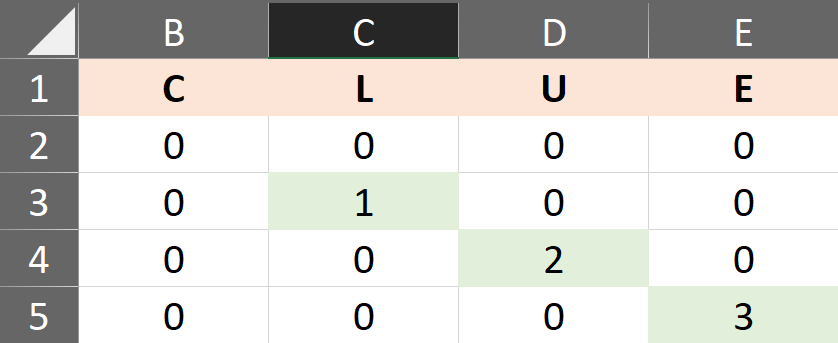

In [ ]:
"""
Если буквы совпадают, мы берем значение из ячейки сверху слева (по диагонали) и прибавляем 1
Формула: cell[i][j] = cell[i-1][j-1] + 1
"""